# Onset detection grid

Spectral flux (`lag=1`, `max_size=1`) vs SuperFlux (`lag=2`, `max_size=3`), peak-pick **Bock online**, $\delta \in \{0.10, 0.20, 0.30, 0.40, 0.50\}$. Scored on `training/validations/` only. No classification.

- **Evaluation:** Table 1 is `mir_eval` precision / recall / F-measure (50 ms window). Table 2 is ME and MAE in milliseconds on **matched** pairs only (same window). Positive ME = late.
- **Visualizations:** one validation sample, CQT with GT / predicted onsets, then the ODF used for peak-picking.


In [2]:
from pathlib import Path

import librosa
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from mir_eval.onset import f_measure as onset_f_measure
from mir_eval.util import match_events

_CANDIDATES = [
    Path(".").resolve(),
    Path("/home/seya/code/chord-detection/training/notebooks/onset-latest"),
    Path("training/notebooks/onset-latest").resolve(),
]
HERE = next(
    p for p in _CANDIDATES
    if (p.parent.parent / "validations" / "normal_sustain.npz").is_file()
)
VALID = HERE.parent.parent / "validations"

AUDIO_SAMPLE_RATE = 48_000
CQT_HOP_LENGTH = 512
CQT_BINS_PER_OCTAVE = 36
CQT_FMIN = librosa.note_to_hz("C1")
WINDOW_S = 0.05
DATASETS = ["normal_sustain", "broken_sustain", "normal_no-sustain"]
ODFS = ["spectral-flux", "superflux"]
ODF_LABEL = {"spectral-flux": "Spectral flux", "superflux": "SuperFlux"}
DELTAS = [0.10, 0.20, 0.30, 0.40, 0.50]
ODF_KW = {
    "spectral-flux": {"lag": 1, "max_size": 1},
    "superflux": {"lag": 2, "max_size": 3},
}
PEAK_PICK = {
    "pre_max": 30,
    "post_max": 1,
    "pre_avg": 100,
    "post_avg": 1,
    "wait": 30,
}

assert all((VALID / f"{name}.npz").is_file() for name in DATASETS), VALID

display(pd.DataFrame(
    [
        {"key": "validations", "value": str(VALID)},
        {"key": "spectral flux", "value": ODF_KW["spectral-flux"]},
        {"key": "superflux", "value": ODF_KW["superflux"]},
        {"key": "delta", "value": DELTAS},
        {"key": "window", "value": f"{WINDOW_S * 1000:.0f} ms"},
        {"key": "peak-pick", "value": "Bock online"},
    ]
))


,key,value
0,validations,/home/seya/code/chord-detection/training/valid...
1,spectral flux,"{'lag': 1, 'max_size': 1}"
2,superflux,"{'lag': 2, 'max_size': 3}"
3,delta,"[0.1, 0.2, 0.3, 0.4, 0.5]"
4,window,50 ms
5,peak-pick,Bock online


## Evaluation

Ten configurations on every validation file. Timing errors use the same 50 ms matching as F-measure.


In [3]:
def load_bundle(name: str):
    z = np.load(VALID / f"{name}.npz", allow_pickle=True)
    return list(z["features"]), list(z["annotations"])


def detect_times(sample_cqt: np.ndarray, odf: str, delta: float) -> np.ndarray:
    envelope = librosa.onset.onset_strength(
        S=sample_cqt,
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        **ODF_KW[odf],
    )
    frames = librosa.onset.onset_detect(
        onset_envelope=envelope,
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        delta=delta,
        **PEAK_PICK,
    )
    return librosa.frames_to_time(
        frames, sr=AUDIO_SAMPLE_RATE, hop_length=CQT_HOP_LENGTH
    ).astype(float)


def score_file(ref: np.ndarray, est: np.ndarray) -> dict:
    ref = np.sort(np.asarray(ref, dtype=float))
    est = np.sort(np.asarray(est, dtype=float))
    f, p, r = onset_f_measure(ref, est, window=WINDOW_S)
    matching = match_events(ref, est, WINDOW_S) if ref.size and est.size else []
    if matching:
        err_s = np.array([est[j] - ref[i] for i, j in matching], dtype=float)
        me_ms = float(err_s.mean() * 1000.0)
        mae_ms = float(np.abs(err_s).mean() * 1000.0)
        err_sum = float(err_s.sum())
        abs_sum = float(np.abs(err_s).sum())
        err_sq = float(np.square(err_s).sum())
        abs_sq = float(np.square(err_s).sum())
    else:
        me_ms = mae_ms = np.nan
        err_sum = abs_sum = err_sq = abs_sq = 0.0
    return {
        "n_ref": int(ref.size),
        "n_est": int(est.size),
        "n_matched": int(len(matching)),
        "precision": float(p),
        "recall": float(r),
        "f-measure": float(f),
        "ME (ms)": me_ms,
        "MAE (ms)": mae_ms,
        "_err_sum": err_sum,
        "_abs_sum": abs_sum,
        "_err_sq": err_sq,
        "_abs_sq": abs_sq,
    }


bundles = {name: load_bundle(name) for name in DATASETS}
rows = []
for odf in ODFS:
    for delta in DELTAS:
        for dataset in DATASETS:
            features, annotations = bundles[dataset]
            for sample_index, (cqt, anns) in enumerate(zip(features, annotations)):
                ref = np.array([ev["start"] for ev in anns], dtype=float)
                est = detect_times(cqt, odf, delta)
                row = score_file(ref, est)
                row.update(
                    {
                        "odf": odf,
                        "delta": delta,
                        "dataset": dataset,
                        "sample_index": sample_index,
                    }
                )
                rows.append(row)

per_file = pd.DataFrame(rows)
display(Markdown(f"Scored **{len(per_file)}** file-level rows."))
display(per_file.groupby(["odf", "delta", "dataset"]).size().unstack("dataset"))

Scored **620** file-level rows.

dataset              broken_sustain  normal_no-sustain  normal_sustain
odf           delta                                                   
spectral-flux 0.1                20                 32              10
              0.2                20                 32              10
              0.3                20                 32              10
              0.4                20                 32              10
              0.5                20                 32              10
superflux     0.1                20                 32              10
              0.2                20                 32              10
              0.3                20                 32              10
              0.4                20                 32              10
              0.5                20                 32              10

## Detection metrics

Per-file `mir_eval` scores, averaged inside each dataset. `n_ref` / `n_est` are totals. The **mean** and **std** rows are the unweighted mean and sample std of the three dataset rows.

In [3]:
ORDER = ["normal_sustain", "broken_sustain", "normal_no-sustain", "mean", "std"]
COUNT_COLS = ["n_ref", "n_est"]
RATE_COLS = ["precision", "recall", "f-measure"]


def with_mean_std(df: pd.DataFrame, value_cols: list[str]) -> pd.DataFrame:
    grouped = df.groupby(["odf", "delta"], as_index=False)
    mean = grouped[value_cols].mean(numeric_only=True)
    std = grouped[value_cols].std(ddof=1, numeric_only=True)
    mean.insert(2, "dataset", "mean")
    std.insert(2, "dataset", "std")
    out = pd.concat([df, mean, std], ignore_index=True)
    out["dataset"] = pd.Categorical(out["dataset"], ORDER)
    return out.sort_values(["odf", "delta", "dataset"]).reset_index(drop=True)


detect = (
    per_file.groupby(["odf", "delta", "dataset"], as_index=False)
    .agg(
        n_ref=("n_ref", "sum"),
        n_est=("n_est", "sum"),
        precision=("precision", "mean"),
        recall=("recall", "mean"),
        **{"f-measure": ("f-measure", "mean")},
    )
)
detect_table = with_mean_std(detect, COUNT_COLS + RATE_COLS)
display(detect_table.round(4))

,odf,delta,dataset,n_ref,n_est,precision,recall,f-measure
0,spectral-flux,0.1,normal_sustain,100.0000,102.0000,0.7182,0.7300,0.7238
1,spectral-flux,0.1,broken_sustain,200.0000,236.0000,0.4852,0.5600,0.5182
2,spectral-flux,0.1,normal_no-sustain,320.0000,381.0000,0.4208,0.4812,0.4463
3,spectral-flux,0.1,mean,206.6667,239.6667,0.5414,0.5904,0.5628
4,spectral-flux,0.1,std,110.1514,139.5361,0.1565,0.1271,0.1440
5,spectral-flux,0.2,normal_sustain,100.0000,100.0000,0.8900,0.8900,0.8900
6,spectral-flux,0.2,broken_sustain,200.0000,202.0000,0.8964,0.9050,0.9005
7,spectral-flux,0.2,normal_no-sustain,320.0000,332.0000,0.8511,0.8750,0.8618
8,spectral-flux,0.2,mean,206.6667,211.3333,0.8792,0.8900,0.8841
9,spectral-flux,0.2,std,110.1514,116.2813,0.0245,0.0150,0.0200


## Timing metrics

ME and MAE on pairs matched inside the 50 ms window, pooled over all matches in the dataset. Positive ME = detection later than the annotation. The **mean** and **std** rows are the unweighted mean and sample std of the three dataset rows.

In [4]:
timing = (
    per_file.groupby(["odf", "delta", "dataset"], as_index=False)
    .agg(
        n_matched=("n_matched", "sum"),
        _err_sum=("_err_sum", "sum"),
        _abs_sum=("_abs_sum", "sum"),
    )
)
n = timing.n_matched.to_numpy(dtype=float)
timing["ME (ms)"] = np.where(n > 0, 1000.0 * timing["_err_sum"] / n, np.nan)
timing["MAE (ms)"] = np.where(n > 0, 1000.0 * timing["_abs_sum"] / n, np.nan)
timing = timing.drop(columns=["_err_sum", "_abs_sum"])
timing_table = with_mean_std(timing, ["n_matched", "ME (ms)", "MAE (ms)"])
display(timing_table.round(3))

,odf,delta,dataset,n_matched,ME (ms),MAE (ms)
0,spectral-flux,0.1,normal_sustain,73.000,-27.895,27.895
1,spectral-flux,0.1,broken_sustain,112.000,-33.432,33.967
2,spectral-flux,0.1,normal_no-sustain,154.000,-36.866,37.411
3,spectral-flux,0.1,mean,113.000,-32.731,33.091
4,spectral-flux,0.1,std,40.509,4.526,4.818
5,spectral-flux,0.2,normal_sustain,89.000,-2.663,17.187
6,spectral-flux,0.2,broken_sustain,181.000,-16.486,19.403
7,spectral-flux,0.2,normal_no-sustain,280.000,-21.323,21.615
8,spectral-flux,0.2,mean,183.333,-13.491,19.402
9,spectral-flux,0.2,std,95.521,9.684,2.214


## Overall

In [3]:
overall = (
    per_file.groupby(["odf", "delta"], as_index=False)
    .agg(
        n_ref=("n_ref", "sum"),
        n_est=("n_est", "sum"),
        n_matched=("n_matched", "sum"),
        _err_sum=("_err_sum", "sum"),
        _abs_sum=("_abs_sum", "sum"),
    )
)
n_ref = overall.n_ref.to_numpy(dtype=float)
n_est = overall.n_est.to_numpy(dtype=float)
n_m = overall.n_matched.to_numpy(dtype=float)
precision = np.divide(n_m, n_est, out=np.full_like(n_m, np.nan), where=n_est > 0)
recall = np.divide(n_m, n_ref, out=np.full_like(n_m, np.nan), where=n_ref > 0)
f_measure = np.divide(
    2.0 * precision * recall,
    precision + recall,
    out=np.full_like(n_m, np.nan),
    where=(precision + recall) > 0,
)
me = np.where(n_m > 0, 1000.0 * overall["_err_sum"].to_numpy() / n_m, np.nan)
mae = np.where(n_m > 0, 1000.0 * overall["_abs_sum"].to_numpy() / n_m, np.nan)
overall = overall.assign(
    precision=precision,
    recall=recall,
    **{"f-measure": f_measure},
    me=me,
    mae=mae,
)[
    [
        "odf", "delta", "n_ref", "n_est", "precision", "recall",
        "f-measure", "n_matched", "me", "mae",
    ]
].sort_values(["odf", "delta"]).reset_index(drop=True)
display(overall.round(4))


,odf,delta,n_ref,n_est,precision,recall,f-measure,n_matched,me,mae
0,spectral-flux,0.1,620,719,0.4715,0.5468,0.5063,339,-33.7994,34.2242
1,spectral-flux,0.2,620,634,0.8675,0.8871,0.8772,550,-16.7115,20.1709
2,spectral-flux,0.3,620,620,0.9355,0.9355,0.9355,580,11.6333,19.6276
3,spectral-flux,0.4,620,594,0.8906,0.8532,0.8715,529,31.7196,32.1619
4,spectral-flux,0.5,620,529,0.8204,0.7000,0.7554,434,38.5983,38.6014
5,superflux,0.1,620,646,0.8282,0.8629,0.8452,535,-26.2480,26.8835
6,superflux,0.2,620,628,0.9411,0.9532,0.9471,591,-7.2752,14.5003
7,superflux,0.3,620,616,0.9464,0.9403,0.9434,583,13.4431,17.2544
8,superflux,0.4,620,599,0.8848,0.8548,0.8696,530,28.7157,28.8805
9,superflux,0.5,620,558,0.7760,0.6984,0.7351,433,37.7460,37.7460


## Result plots

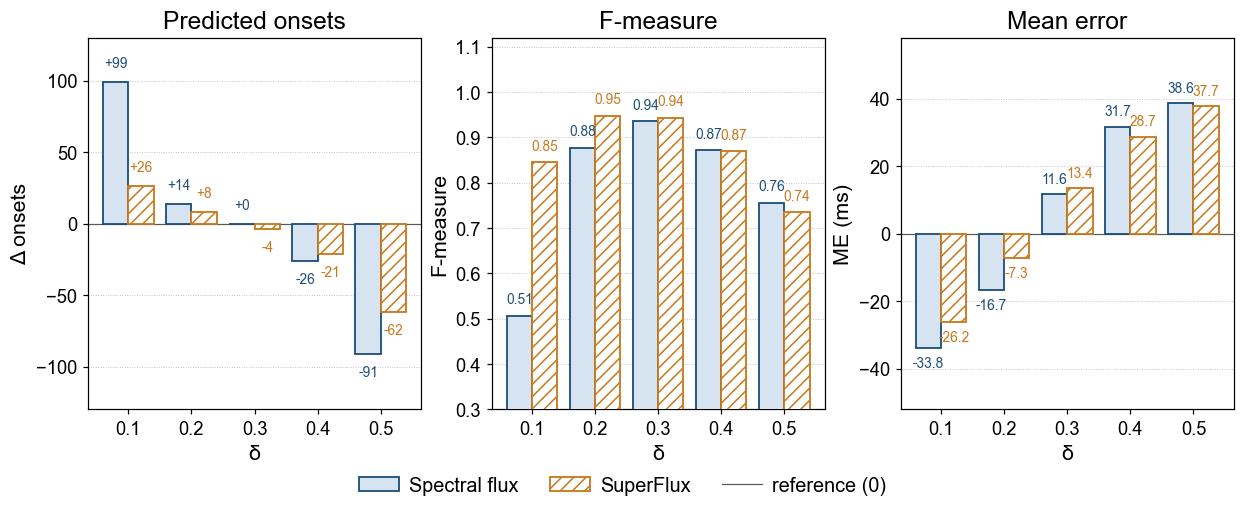

In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

NAVY = "#1f4e79"
ACCENT = "#c8791e"
FILL = "#d6e3f0"
bar_kw = dict(linewidth=1.2, zorder=3)
width = 0.40
x = np.arange(len(DELTAS))
N_REF = 620

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.frameon": False,
    "figure.dpi": 110,
})

flux = overall.loc[overall.odf == "spectral-flux"].sort_values("delta")
super_ = overall.loc[overall.odf == "superflux"].sort_values("delta")
flux_dn = flux.n_est.to_numpy() - N_REF
super_dn = super_.n_est.to_numpy() - N_REF


def grouped_bars(ax, flux_vals, super_vals, ylabel, ylim, fmt, pad):
    ax.bar(
        x - width / 2, flux_vals, width,
        facecolor=FILL, edgecolor=NAVY, label="Spectral flux", **bar_kw,
    )
    ax.bar(
        x + width / 2, super_vals, width,
        facecolor="white", edgecolor=ACCENT, hatch="///", label="SuperFlux", **bar_kw,
    )
    ax.set_xticks(x, [f"{d:.1f}" for d in DELTAS])
    ax.set_xlabel("δ")
    ax.set_ylabel(ylabel)
    ax.set_ylim(*ylim)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
    for xi, fv, sv in zip(x, flux_vals, super_vals):
        f_off = -pad if fv < 0 else pad
        s_off = -pad if sv < 0 else pad
        ax.text(
            xi - width / 2, fv + f_off, fmt.format(fv),
            ha="center", va="top" if fv < 0 else "bottom",
            fontsize=9, color=NAVY,
        )
        ax.text(
            xi + width / 2, sv + s_off, fmt.format(sv),
            ha="center", va="top" if sv < 0 else "bottom",
            fontsize=9, color=ACCENT,
        )


fig, axes = plt.subplots(1, 3, figsize=(11.2, 4.6), layout="constrained")
grouped_bars(
    axes[0], flux_dn, super_dn,
    "Δ onsets", (-130, 130), "{:+.0f}", 8,
)
axes[0].axhline(0, color="0.35", linewidth=0.8)
axes[0].set_title("Predicted onsets")

grouped_bars(
    axes[1], flux["f-measure"].to_numpy(), super_["f-measure"].to_numpy(),
    "F-measure", (0.30, 1.12), "{:.2f}", 0.02,
)
axes[1].set_title("F-measure")

grouped_bars(
    axes[2], flux.me.to_numpy(), super_.me.to_numpy(),
    "ME (ms)", (-52, 58), "{:.1f}", 2.4,
)
axes[2].axhline(0, color="0.35", linewidth=0.8)
axes[2].set_title("Mean error")

fig.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, facecolor=FILL, edgecolor=NAVY, linewidth=1.2),
        plt.Rectangle(
            (0, 0), 1, 1, facecolor="white", edgecolor=ACCENT, linewidth=1.2, hatch="///",
        ),
        Line2D([0], [0], color="0.35", lw=0.8, label="reference"),
    ],
    labels=["Spectral flux", "SuperFlux", "reference (0)"],
    loc="outside lower center", ncol=3, frameon=False,
    columnspacing=1.6, handletextpad=0.5,
)
plt.show()


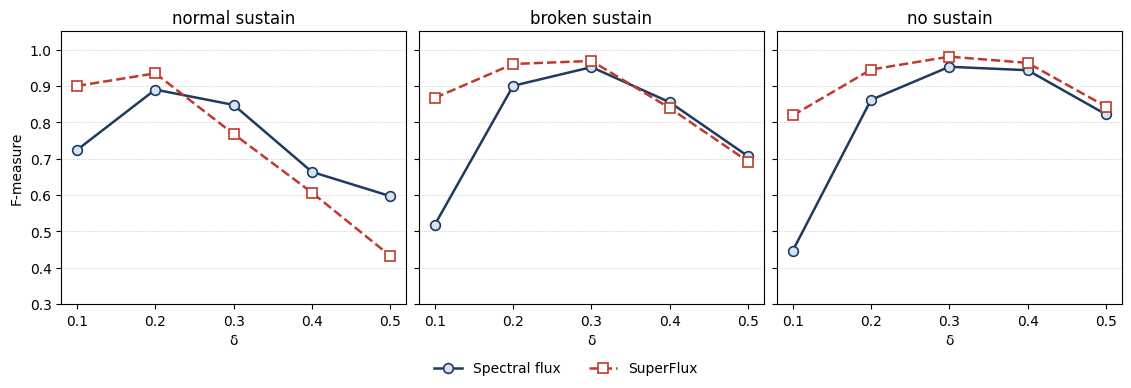

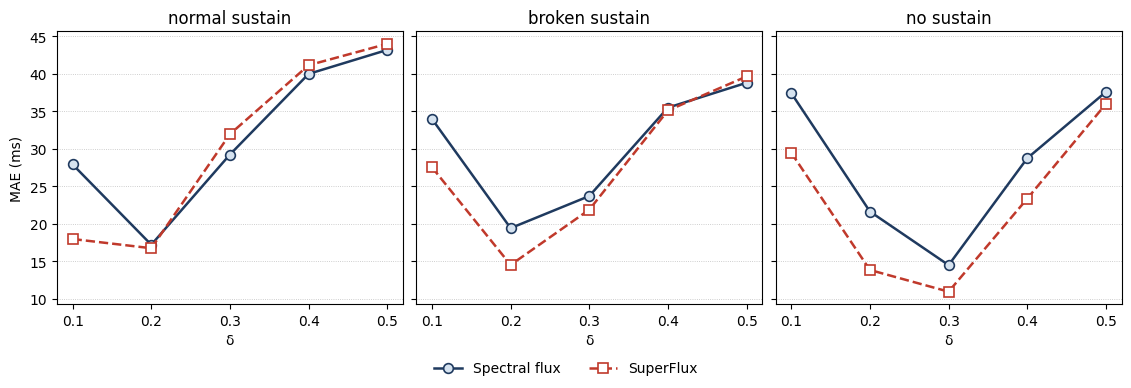

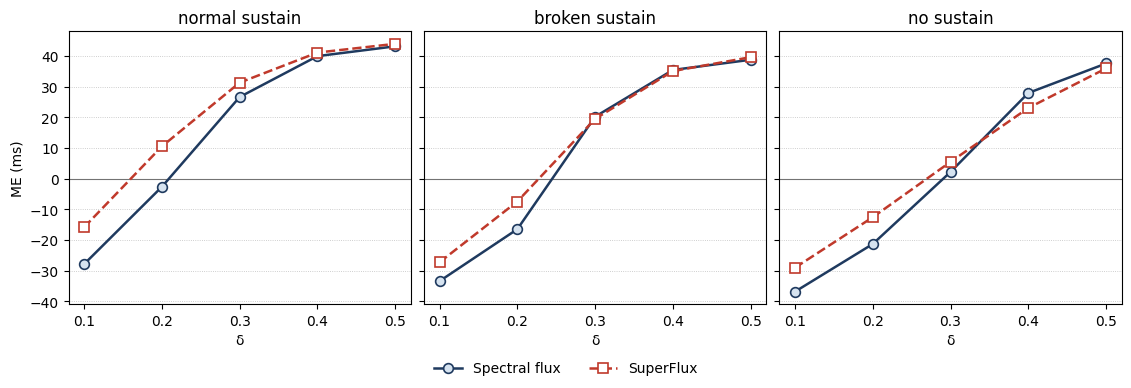

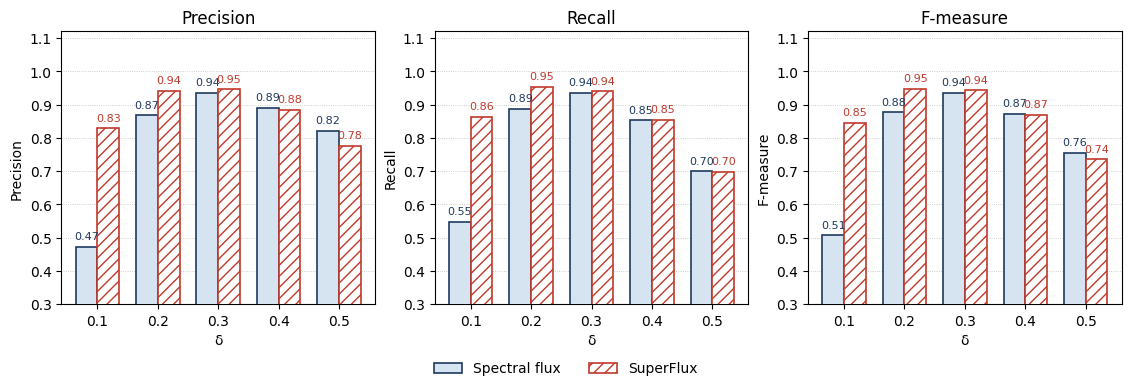

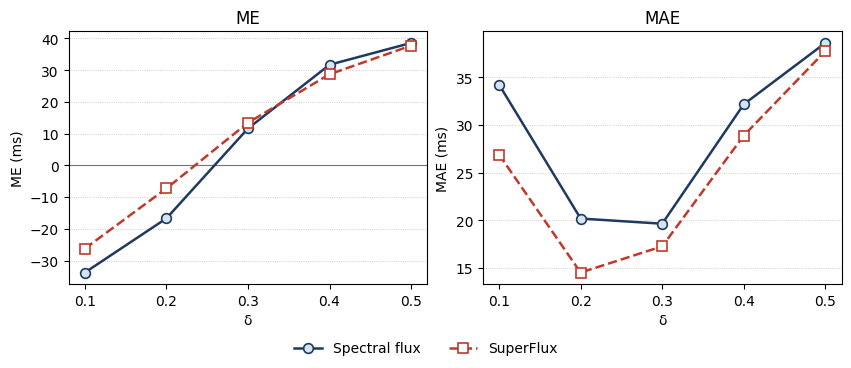

In [4]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

NAVY = "#1f3a5f"
ACCENT = "#c0392b"
FILL = "#d6e3f0"
SETS = ["normal_sustain", "broken_sustain", "normal_no-sustain"]
SET_LABEL = {
    "normal_sustain": "normal sustain",
    "broken_sustain": "broken sustain",
    "normal_no-sustain": "no sustain",
}
ODF_ORDER = ["spectral-flux", "superflux"]
ODF_NAME = {"spectral-flux": "Spectral flux", "superflux": "SuperFlux"}
line_kw = {
    "spectral-flux": dict(
        color=NAVY, marker="o", ls="-", lw=1.8, ms=7,
        mfc=FILL, mec=NAVY, mew=1.2, zorder=3,
    ),
    "superflux": dict(
        color=ACCENT, marker="s", ls="--", lw=1.8, ms=7,
        mfc="white", mec=ACCENT, mew=1.2, zorder=3,
    ),
}
bar_kw = dict(linewidth=1.2, zorder=3)
width = 0.36

by_set = (
    per_file.groupby(["odf", "delta", "dataset"], as_index=False)
    .agg(
        precision=("precision", "mean"),
        recall=("recall", "mean"),
        **{"f-measure": ("f-measure", "mean")},
        n_matched=("n_matched", "sum"),
        _err_sum=("_err_sum", "sum"),
        _abs_sum=("_abs_sum", "sum"),
    )
)
n_set = by_set.n_matched.to_numpy(dtype=float)
by_set["me"] = np.where(n_set > 0, 1000.0 * by_set["_err_sum"] / n_set, np.nan)
by_set["mae"] = np.where(n_set > 0, 1000.0 * by_set["_abs_sum"] / n_set, np.nan)


def odf_slice(df, odf, dataset=None):
    sub = df.loc[df.odf == odf]
    if dataset is not None:
        sub = sub.loc[sub.dataset == dataset]
    return sub.sort_values("delta")


def style_ax(ax):
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
    ax.set_xticks(DELTAS)
    ax.set_xlabel("δ")


def plot_set_lines(axes, column, ylabel, ylim=None, zero=False):
    for ax, dataset in zip(axes, SETS):
        for odf in ODF_ORDER:
            s = odf_slice(by_set, odf, dataset)
            ax.plot(s.delta, s[column], **line_kw[odf])
        ax.set_title(SET_LABEL[dataset])
        style_ax(ax)
        if ylim is not None:
            ax.set_ylim(*ylim)
        if zero:
            ax.axhline(0.0, color="0.45", lw=0.8, zorder=1)
    axes[0].set_ylabel(ylabel)


def odf_handles():
    return [
        Line2D([0], [0], **line_kw["spectral-flux"], label="Spectral flux"),
        Line2D([0], [0], **line_kw["superflux"], label="SuperFlux"),
    ]


fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.8), layout="constrained", sharey=True)
plot_set_lines(axes, "f-measure", "F-measure", ylim=(0.30, 1.05))
fig.legend(handles=odf_handles(), loc="outside lower center", ncol=2, frameon=False)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.8), layout="constrained", sharey=True)
plot_set_lines(axes, "mae", "MAE (ms)")
fig.legend(handles=odf_handles(), loc="outside lower center", ncol=2, frameon=False)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.8), layout="constrained", sharey=True)
plot_set_lines(axes, "me", "ME (ms)", zero=True)
fig.legend(handles=odf_handles(), loc="outside lower center", ncol=2, frameon=False)
plt.show()

x = np.arange(len(DELTAS))


def grouped_odf_bars(ax, flux_vals, super_vals, ylabel, ylim, annotate=True, fmt="{:.2f}", pad=None):
    ax.bar(
        x - width / 2, flux_vals, width,
        facecolor=FILL, edgecolor=NAVY, **bar_kw,
    )
    ax.bar(
        x + width / 2, super_vals, width,
        facecolor="white", edgecolor=ACCENT, hatch="///", **bar_kw,
    )
    ax.set_xticks(x, [f"{d:.1f}" for d in DELTAS])
    ax.set_xlabel("δ")
    ax.set_ylabel(ylabel)
    ax.set_ylim(*ylim)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
    if annotate:
        if pad is None:
            pad = 0.02 * (ylim[1] - ylim[0])
        for xi, fv, sv in zip(x, flux_vals, super_vals):
            ax.text(
                xi - width / 2, fv + pad, fmt.format(fv),
                ha="center", va="bottom", fontsize=8, color=NAVY,
            )
            ax.text(
                xi + width / 2, sv + pad, fmt.format(sv),
                ha="center", va="bottom", fontsize=8, color=ACCENT,
            )


fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.8), layout="constrained")
for ax, col, title in zip(
    axes,
    ["precision", "recall", "f-measure"],
    ["Precision", "Recall", "F-measure"],
):
    flux = odf_slice(overall, "spectral-flux")[col].to_numpy()
    super_ = odf_slice(overall, "superflux")[col].to_numpy()
    grouped_odf_bars(ax, flux, super_, title, (0.30, 1.12))
    ax.set_title(title)
fig.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, facecolor=FILL, edgecolor=NAVY, linewidth=1.2),
        plt.Rectangle(
            (0, 0), 1, 1, facecolor="white", edgecolor=ACCENT, linewidth=1.2, hatch="///",
        ),
    ],
    labels=["Spectral flux", "SuperFlux"],
    loc="outside lower center", ncol=2, frameon=False,
)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.6), layout="constrained")
for odf in ODF_ORDER:
    s = odf_slice(overall, odf)
    axes[0].plot(s.delta, s.me, **line_kw[odf])
    axes[1].plot(s.delta, s.mae, **line_kw[odf])
axes[0].axhline(0.0, color="0.45", lw=0.8, zorder=1)
axes[0].set_ylabel("ME (ms)")
axes[0].set_title("ME")
axes[1].set_ylabel("MAE (ms)")
axes[1].set_title("MAE")
for ax in axes:
    style_ax(ax)
fig.legend(handles=odf_handles(), loc="outside lower center", ncol=2, frameon=False)
plt.show()


## Chord pairs

Consecutive annotated chords (octave stripped). An onset is counted as detected if a peak falls within the 50 ms window of the *second* chord. All three sets are pooled.

**Detectors compared here:** SuperFlux $\delta=0.20$ (grid default) and spectral flux $\delta=0.30$ (best flux cell on the grid). Failures are split into SuperFlux only, flux only, and both.

In [4]:
_QUAL_MAP = {"major": "maj", "minor": "min", "diminished": "dim"}
ROOTS = ["C", "C♯", "D", "D♯", "E", "F", "F♯", "G", "G♯", "A", "A♯", "B"]
QUALS = ["maj", "min", "dim"]
CLASS_ORDER = [f"{root} {qual}" for root in ROOTS for qual in QUALS]
PAIR_DELTA = 0.20
FLUX_DELTA = 0.30


def parse_chord(raw: str) -> tuple[str, str, str]:
    parts = str(raw).split("_")
    root = parts[0].replace("#", "♯")
    qual = _QUAL_MAP.get(parts[1], parts[1]) if len(parts) > 1 else ""
    return f"{root} {qual}", root, qual


pair_rows = []
for odf in ODFS:
    for delta in DELTAS:
        for dataset in DATASETS:
            features, annotations = bundles[dataset]
            for sample_index, (cqt, anns) in enumerate(zip(features, annotations)):
                ref = np.array([ev["start"] for ev in anns], dtype=float)
                est = detect_times(cqt, odf, delta)
                matching = match_events(ref, est, WINDOW_S) if ref.size and est.size else []
                hit = {int(i) for i, _j in matching}
                for k in range(len(anns) - 1):
                    from_lab, from_root, from_qual = parse_chord(anns[k]["chord"])
                    to_lab, to_root, to_qual = parse_chord(anns[k + 1]["chord"])
                    pair_rows.append(
                        {
                            "odf": odf,
                            "delta": delta,
                            "dataset": dataset,
                            "sample_index": sample_index,
                            "pair_k": k,
                            "from": from_lab,
                            "to": to_lab,
                            "from_root": from_root,
                            "to_root": to_root,
                            "from_qual": from_qual,
                            "to_qual": to_qual,
                            "same_root": from_root == to_root,
                            "detected": int((k + 1) in hit),
                        }
                    )

pairs = pd.DataFrame(pair_rows)
OUT = HERE / "results"
OUT.mkdir(exist_ok=True)
pairs.to_csv(OUT / "onset_pairs.csv", index=False)
display(Markdown(
    f"Scored **{len(pairs):,}** transitions "
    f"({pairs.delta.nunique()} δ × {pairs.odf.nunique()} ODFs × "
    f"{int(len(pairs) / (len(ODFS) * len(DELTAS))):,} pairs in the three sets)."
))


Scored **5,580** transitions (5 δ × 2 ODFs × 558 pairs in the three sets).

In [5]:
def summarize_pairs(df: pd.DataFrame, keys: list[str]) -> pd.DataFrame:
    out = (
        df.groupby(keys, as_index=False)
        .agg(n=("detected", "size"), detected=("detected", "sum"))
    )
    out["missed"] = out.n - out.detected
    out["recall"] = np.where(out.n > 0, out.detected / out.n, np.nan)
    return out.sort_values(
        ["missed", "n", *keys], ascending=[False, False] + [True] * len(keys)
    ).reset_index(drop=True)


def pair_slice(odf: str, delta: float) -> pd.DataFrame:
    return pairs.loc[(pairs.odf == odf) & (pairs.delta == delta)].copy()


def show_pair_block(title: str, df: pd.DataFrame):
    display(Markdown(title))
    display(df.round(3))


focus = pair_slice("superflux", PAIR_DELTA)
flux_focus = pair_slice("spectral-flux", FLUX_DELTA)

JOIN = ["dataset", "sample_index", "pair_k"]
joint = focus.rename(columns={"detected": "sf_ok"}).merge(
    flux_focus[JOIN + ["fx_ok"] if "fx_ok" in flux_focus.columns else JOIN + ["detected"]].rename(
        columns={"detected": "fx_ok"}
    ),
    on=JOIN,
    how="inner",
    validate="one_to_one",
)
joint["fail_sf"] = (joint.sf_ok == 0).astype(int)
joint["fail_fx"] = (joint.fx_ok == 0).astype(int)
joint["fail_both"] = ((joint.sf_ok == 0) & (joint.fx_ok == 0)).astype(int)
joint["fail_sf_only"] = ((joint.sf_ok == 0) & (joint.fx_ok == 1)).astype(int)
joint["fail_fx_only"] = ((joint.sf_ok == 1) & (joint.fx_ok == 0)).astype(int)
joint["hit_both"] = ((joint.sf_ok == 1) & (joint.fx_ok == 1)).astype(int)


def summarize_failures(df: pd.DataFrame, keys: list[str]) -> pd.DataFrame:
    out = (
        df.groupby(keys, as_index=False)
        .agg(
            n=("sf_ok", "size"),
            sf_detected=("sf_ok", "sum"),
            fx_detected=("fx_ok", "sum"),
            fail_sf=("fail_sf", "sum"),
            fail_fx=("fail_fx", "sum"),
            fail_both=("fail_both", "sum"),
            fail_sf_only=("fail_sf_only", "sum"),
            fail_fx_only=("fail_fx_only", "sum"),
            hit_both=("hit_both", "sum"),
        )
    )
    out["sf_recall"] = np.where(out.n > 0, out.sf_detected / out.n, np.nan)
    out["fx_recall"] = np.where(out.n > 0, out.fx_detected / out.n, np.nan)
    return out.sort_values(
        ["fail_both", "fail_sf", "fail_fx", "n", *keys],
        ascending=[False, False, False, False] + [True] * len(keys),
    ).reset_index(drop=True)


chord_pairs = summarize_pairs(focus, ["from", "to"])
flux_pairs = summarize_pairs(flux_focus, ["from", "to"])
chord_pairs.to_csv(OUT / "onset_pairs_superflux_d020.csv", index=False)
flux_pairs.to_csv(OUT / "onset_pairs_spectral_flux_d030.csv", index=False)

fail_chords = summarize_failures(joint, ["from", "to"])
fail_quals = summarize_failures(joint, ["from_qual", "to_qual"])
fail_chords.to_csv(OUT / "onset_pairs_fail_sf020_flux030.csv", index=False)

overview = pd.DataFrame(
    [
        {
            "slice": f"SuperFlux δ={PAIR_DELTA:.2f}",
            "n": int(focus.shape[0]),
            "detected": int(focus.detected.sum()),
            "missed": int((1 - focus.detected).sum()),
            "recall": float(focus.detected.mean()),
        },
        {
            "slice": f"Spectral flux δ={FLUX_DELTA:.2f}",
            "n": int(flux_focus.shape[0]),
            "detected": int(flux_focus.detected.sum()),
            "missed": int((1 - flux_focus.detected).sum()),
            "recall": float(flux_focus.detected.mean()),
        },
        {
            "slice": "both hit",
            "n": int(joint.shape[0]),
            "detected": int(joint.hit_both.sum()),
            "missed": int(joint.shape[0] - joint.hit_both.sum()),
            "recall": float(joint.hit_both.mean()),
        },
        {
            "slice": "both miss",
            "n": int(joint.shape[0]),
            "detected": int(joint.fail_both.sum()),
            "missed": int(joint.fail_both.sum()),
            "recall": float(joint.fail_both.mean()),
        },
        {
            "slice": "SuperFlux miss, flux hit",
            "n": int(joint.shape[0]),
            "detected": int(joint.fail_sf_only.sum()),
            "missed": int(joint.fail_sf_only.sum()),
            "recall": float(joint.fail_sf_only.mean()),
        },
        {
            "slice": "flux miss, SuperFlux hit",
            "n": int(joint.shape[0]),
            "detected": int(joint.fail_fx_only.sum()),
            "missed": int(joint.fail_fx_only.sum()),
            "recall": float(joint.fail_fx_only.mean()),
        },
    ]
)
show_pair_block(
    f"**SuperFlux δ={PAIR_DELTA:.2f} vs spectral flux δ={FLUX_DELTA:.2f}** — "
    f"{len(joint)} aligned transitions",
    overview,
)
show_pair_block("**Quality pairs — SuperFlux δ=0.20**", summarize_pairs(focus, ["from_qual", "to_qual"]))
show_pair_block("**Quality pairs — spectral flux δ=0.30**", summarize_pairs(flux_focus, ["from_qual", "to_qual"]))
show_pair_block(
    "**Quality pairs — failure split (both / SuperFlux only / flux only)**",
    fail_quals,
)
show_pair_block("**Same root vs different root — SuperFlux δ=0.20**", summarize_pairs(focus, ["same_root"]))
show_pair_block("**Same root vs different root — spectral flux δ=0.30**", summarize_pairs(flux_focus, ["same_root"]))
show_pair_block(
    "**Missed chord pairs — SuperFlux δ=0.20**",
    chord_pairs.loc[chord_pairs.missed > 0],
)
show_pair_block(
    "**Missed chord pairs — spectral flux δ=0.30**",
    flux_pairs.loc[flux_pairs.missed > 0],
)
show_pair_block(
    "**Chord pairs missed by both**",
    fail_chords.loc[fail_chords.fail_both > 0],
)
show_pair_block(
    "**Chord pairs missed by SuperFlux only**",
    fail_chords.loc[fail_chords.fail_sf_only > 0],
)
show_pair_block(
    "**Chord pairs missed by spectral flux only**",
    fail_chords.loc[fail_chords.fail_fx_only > 0],
)

**SuperFlux δ=0.20 vs spectral flux δ=0.30** — 558 aligned transitions

,slice,n,detected,missed,recall
0,SuperFlux δ=0.20,558,547,11,0.980
1,Spectral flux δ=0.30,558,535,23,0.959
2,both hit,558,533,25,0.955
3,both miss,558,9,9,0.016
4,"SuperFlux miss, flux hit",558,2,2,0.004
5,"flux miss, SuperFlux hit",558,14,14,0.025


**Quality pairs — SuperFlux δ=0.20**

,from_qual,to_qual,n,detected,missed,recall
0,maj,min,61,58,3,0.951
1,min,maj,67,65,2,0.970
2,dim,dim,64,62,2,0.969
3,min,min,69,68,1,0.986
4,maj,dim,62,61,1,0.984
5,dim,maj,61,60,1,0.984
6,min,dim,53,52,1,0.981
7,maj,maj,65,65,0,1.000
8,dim,min,56,56,0,1.000


**Quality pairs — spectral flux δ=0.30**

...

,from,to,n,sf_detected,fx_detected,fail_sf,fail_fx,fail_both,fail_sf_only,fail_fx_only,hit_both,sf_recall,fx_recall
0,B maj,E min,2,1,1,1,1,1,0,0,1,0.5,0.5
1,C maj,F♯ min,2,1,1,1,1,1,0,0,1,0.5,0.5
2,C♯ dim,C dim,2,1,1,1,1,1,0,0,1,0.5,0.5
3,D♯ maj,A♯ dim,2,1,1,1,1,1,0,0,1,0.5,0.5
4,F dim,A♯ dim,2,1,1,1,1,1,0,0,1,0.5,0.5
5,F min,B maj,2,1,1,1,1,1,0,0,1,0.5,0.5
6,A♯ min,F♯ min,1,0,0,1,1,1,0,0,0,0.0,0.0
7,C min,B maj,1,0,0,1,1,1,0,0,0,0.0,0.0
8,F dim,D maj,1,0,0,1,1,1,0,0,0,0.0,0.0


**Chord pairs missed by SuperFlux only**

,from,to,n,sf_detected,fx_detected,fail_sf,fail_fx,fail_both,fail_sf_only,fail_fx_only,hit_both,sf_recall,fx_recall
9,C min,D♯ dim,3,2,3,1,0,0,1,0,2,0.667,1.0
10,D♯ maj,C min,2,1,2,1,0,0,1,0,1,0.500,1.0


**Chord pairs missed by spectral flux only**

,from,to,n,sf_detected,fx_detected,fail_sf,fail_fx,fail_both,fail_sf_only,fail_fx_only,hit_both,sf_recall,fx_recall
11,G♯ dim,C♯ min,3,3,2,0,1,0,0,1,2,1.0,0.667
12,B min,A♯ min,1,1,0,0,1,0,0,1,0,1.0,0.000
13,C dim,E maj,1,1,0,0,1,0,0,1,0,1.0,0.000
14,C♯ dim,D♯ min,1,1,0,0,1,0,0,1,0,1.0,0.000
15,C♯ dim,F♯ dim,1,1,0,0,1,0,0,1,0,1.0,0.000
16,C♯ min,A min,1,1,0,0,1,0,0,1,0,1.0,0.000
17,D♯ maj,C dim,1,1,0,0,1,0,0,1,0,1.0,0.000
18,D♯ maj,F♯ min,1,1,0,0,1,0,0,1,0,1.0,0.000
19,E maj,D♯ maj,1,1,0,0,1,0,0,1,0,1.0,0.000
20,F dim,A min,1,1,0,0,1,0,0,1,0,1.0,0.000


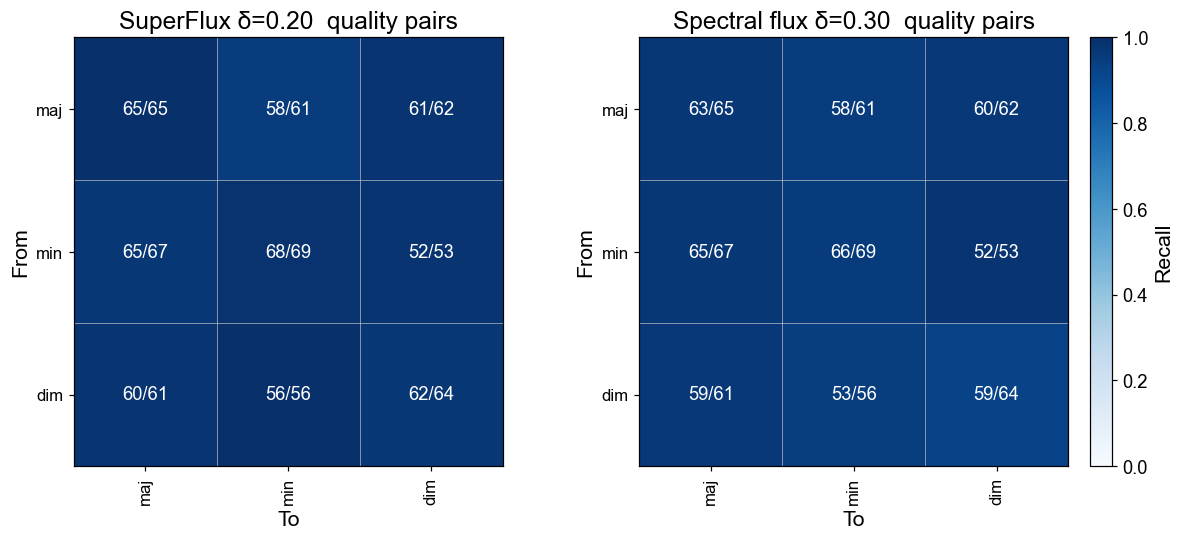

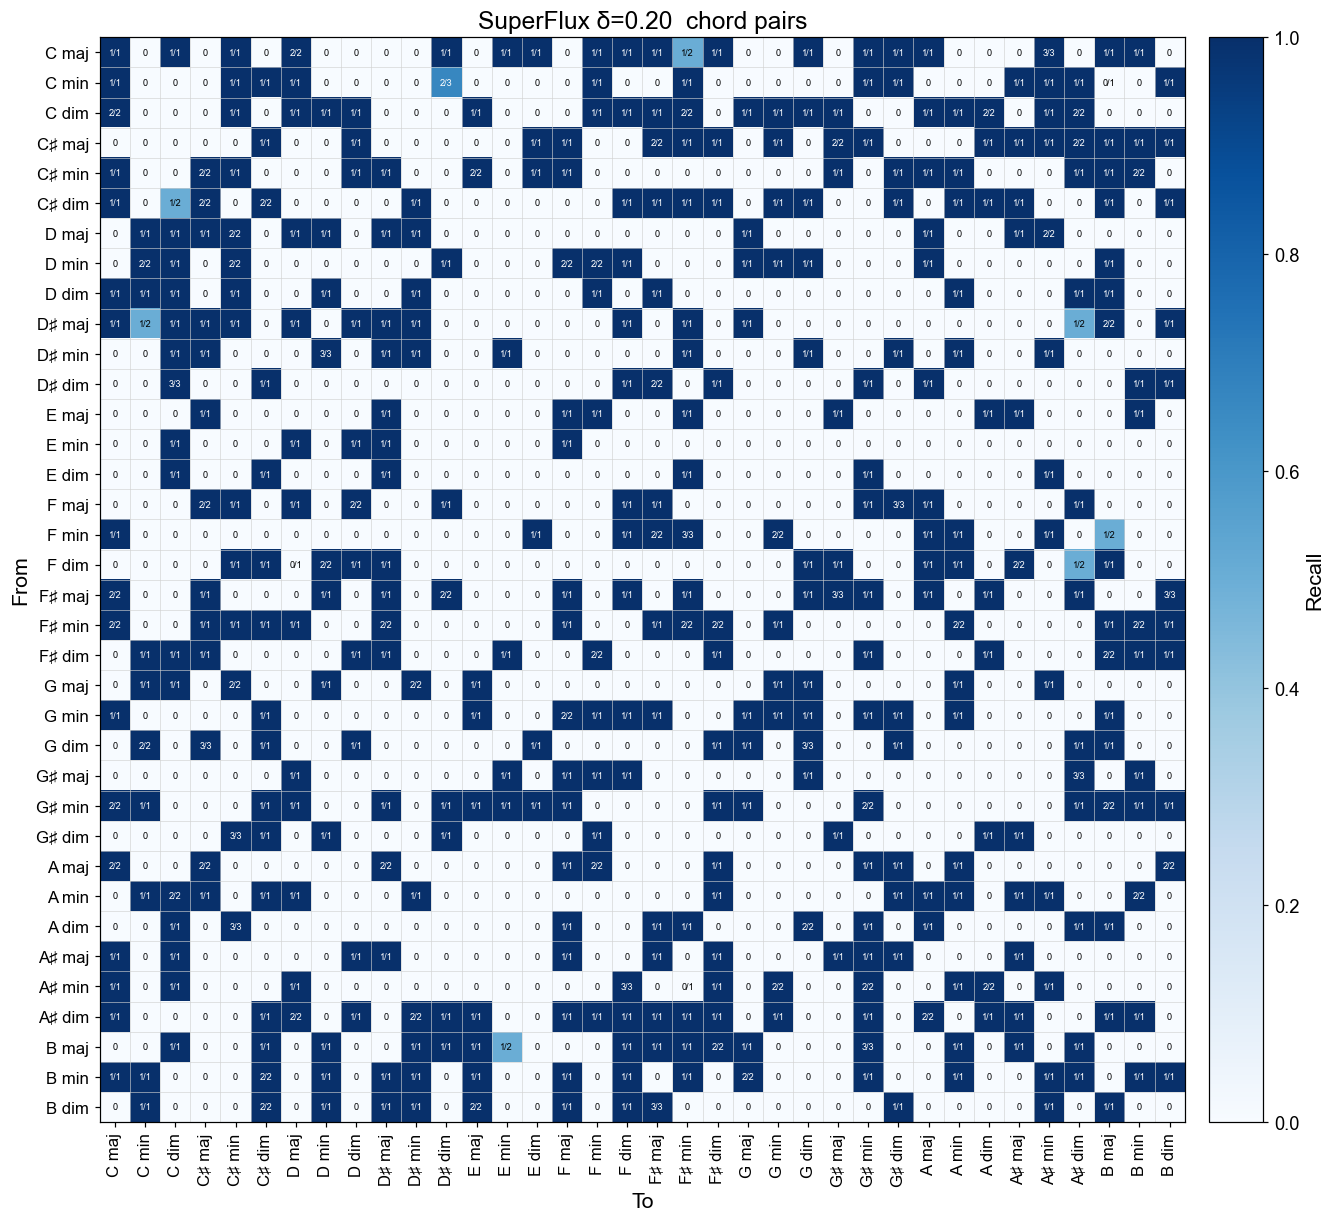

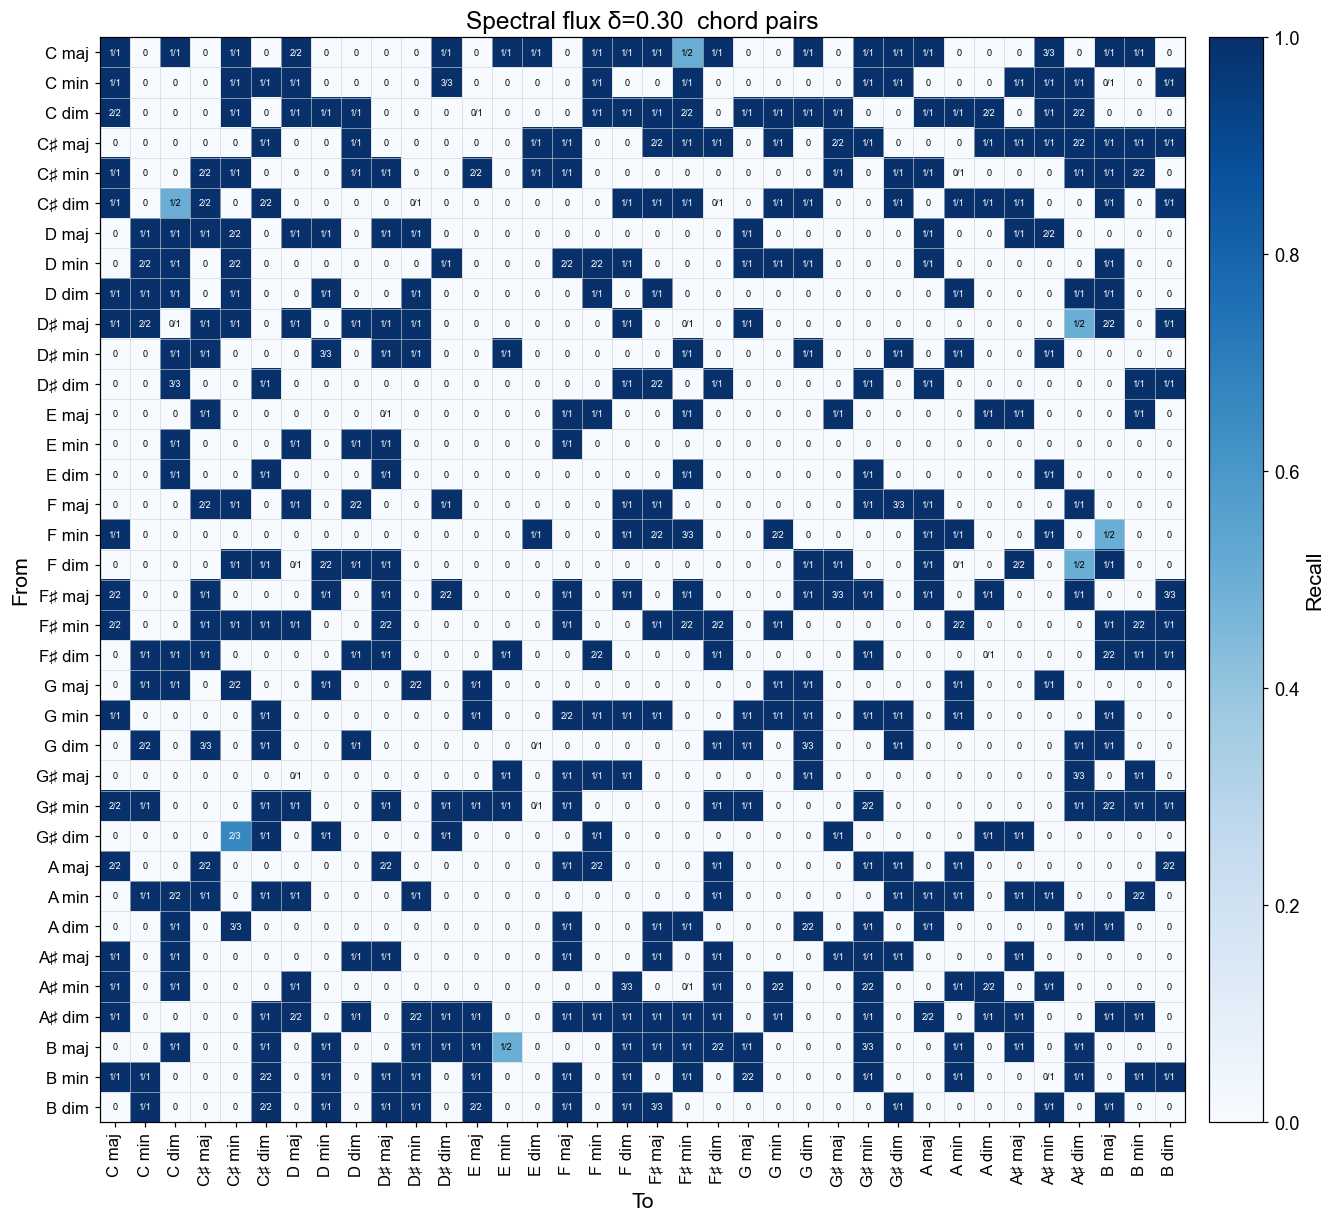

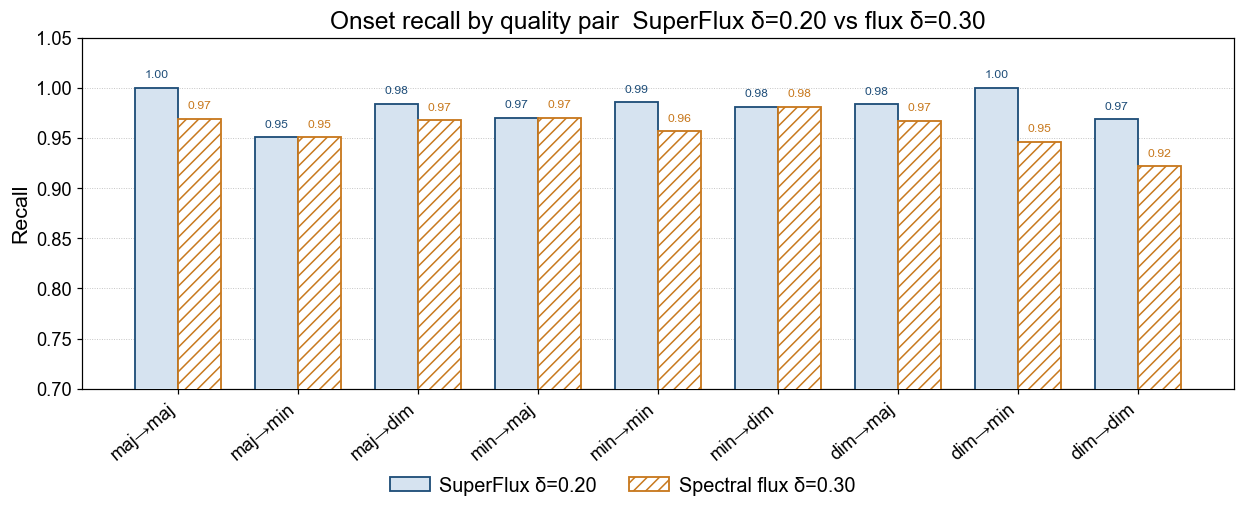

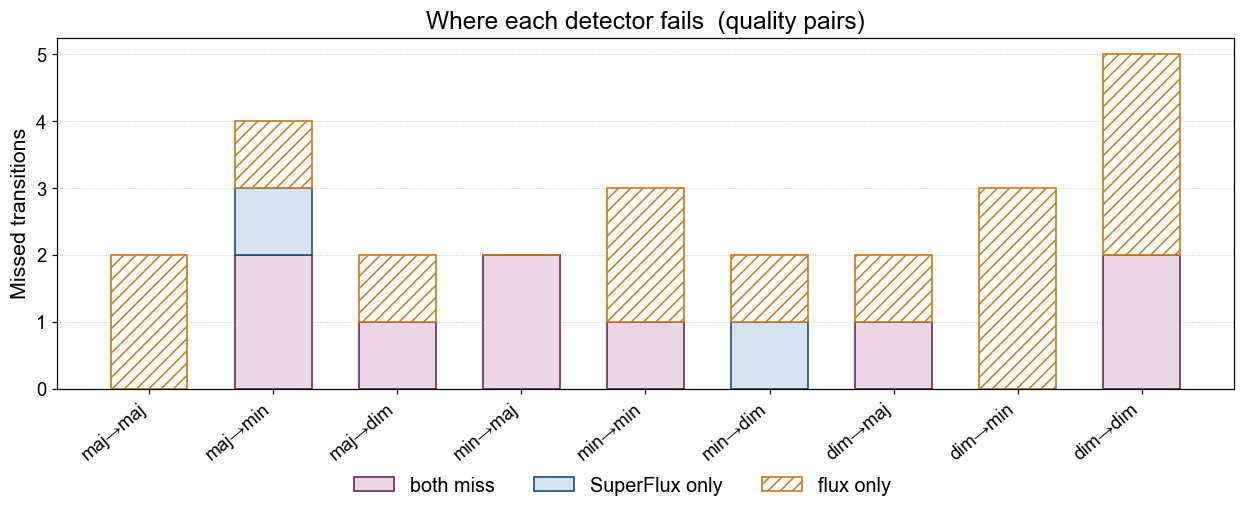

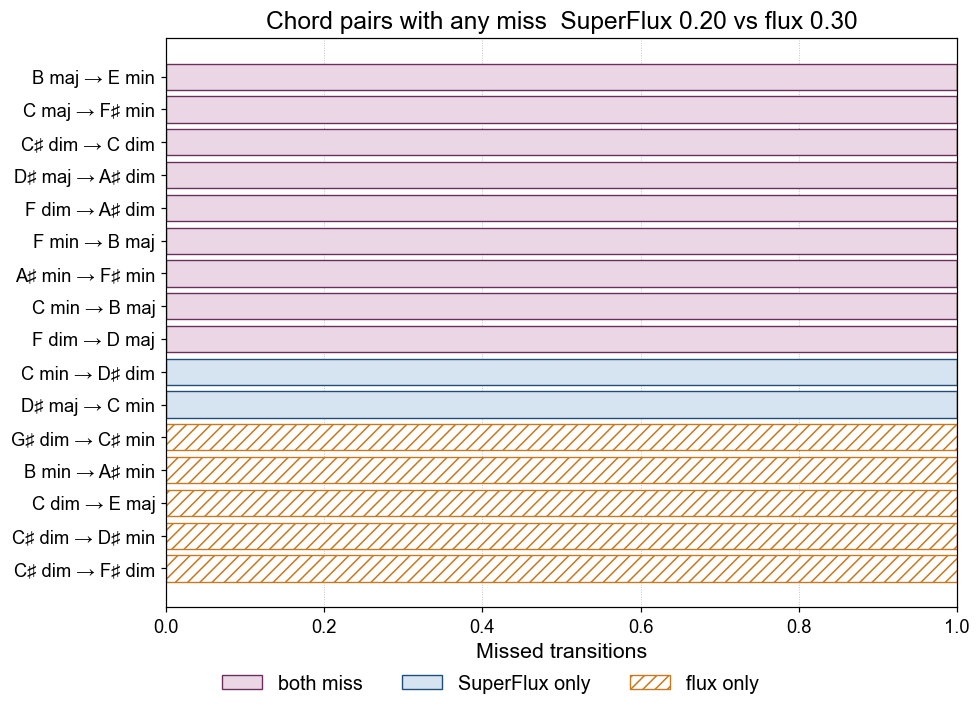

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

NAVY = "#1f4e79"
ACCENT = "#c8791e"
BOTH = "#6b2d5c"
FILL = "#d6e3f0"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.frameon": False,
    "figure.dpi": 110,
})


def counts_matrix(df: pd.DataFrame, row_key: str, col_key: str, rows: list[str], cols: list[str]):
    n = (
        df.groupby([row_key, col_key])
        .size()
        .unstack(col_key)
        .reindex(index=rows, columns=cols)
        .fillna(0)
        .astype(int)
    )
    hit = (
        df.groupby([row_key, col_key])["detected"]
        .sum()
        .unstack(col_key)
        .reindex(index=rows, columns=cols)
        .fillna(0)
        .astype(int)
    )
    return hit, n


def draw_count_matrix(ax, hit: pd.DataFrame, n: pd.DataFrame, title: str, cell_fs: int):
    recall = np.divide(
        hit.to_numpy(dtype=float),
        n.to_numpy(dtype=float),
        out=np.zeros(hit.shape, dtype=float),
        where=n.to_numpy() > 0,
    )
    im = ax.imshow(recall, cmap="Blues", vmin=0.0, vmax=1.0, interpolation="nearest")
    labels_r = list(hit.index)
    labels_c = list(hit.columns)
    nr, nc = hit.shape
    ax.set_xticks(np.arange(nc), labels_c, rotation=90, fontsize=11)
    ax.set_yticks(np.arange(nr), labels_r, fontsize=11)
    ax.set_xticks(np.arange(nc) - 0.5, minor=True)
    ax.set_yticks(np.arange(nr) - 0.5, minor=True)
    ax.grid(which="minor", color="0.82", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_xlabel("To")
    ax.set_ylabel("From")
    ax.set_title(title)
    for i in range(nr):
        for j in range(nc):
            nn = int(n.iloc[i, j])
            hh = int(hit.iloc[i, j])
            text = f"{hh}/{nn}" if nn else "0"
            ax.text(
                j, i, text,
                ha="center", va="center", fontsize=cell_fs,
                color="white" if nn and recall[i, j] >= 0.55 else "black",
            )
    return im


qual_hit, qual_n = counts_matrix(focus, "from_qual", "to_qual", QUALS, QUALS)
fx_qual_hit, fx_qual_n = counts_matrix(flux_focus, "from_qual", "to_qual", QUALS, QUALS)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8), layout="constrained")
im0 = draw_count_matrix(axes[0], qual_hit, qual_n, f"SuperFlux δ={PAIR_DELTA:.2f}  quality pairs", 12)
im1 = draw_count_matrix(axes[1], fx_qual_hit, fx_qual_n, f"Spectral flux δ={FLUX_DELTA:.2f}  quality pairs", 12)
fig.colorbar(im1, ax=axes, fraction=0.046, pad=0.02, label="Recall")
plt.show()

class_hit, class_n = counts_matrix(focus, "from", "to", CLASS_ORDER, CLASS_ORDER)
fig, ax = plt.subplots(figsize=(12.4, 11.0), layout="constrained")
im = draw_count_matrix(ax, class_hit, class_n, f"SuperFlux δ={PAIR_DELTA:.2f}  chord pairs", 6)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Recall")
plt.show()

fx_class_hit, fx_class_n = counts_matrix(flux_focus, "from", "to", CLASS_ORDER, CLASS_ORDER)
fig, ax = plt.subplots(figsize=(12.4, 11.0), layout="constrained")
im = draw_count_matrix(ax, fx_class_hit, fx_class_n, f"Spectral flux δ={FLUX_DELTA:.2f}  chord pairs", 6)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Recall")
plt.show()

bar_kw = dict(linewidth=1.2, zorder=3)
width = 0.36
qual_keys = [f"{a}→{b}" for a in QUALS for b in QUALS]
sf_rec, fx_rec = [], []
for a in QUALS:
    for b in QUALS:
        sf_n = int(qual_n.loc[a, b])
        sf_rec.append(float(qual_hit.loc[a, b] / sf_n) if sf_n else np.nan)
        fx_n = int(fx_qual_n.loc[a, b])
        fx_rec.append(float(fx_qual_hit.loc[a, b] / fx_n) if fx_n else np.nan)
x = np.arange(len(qual_keys))
fig, ax = plt.subplots(figsize=(11.2, 4.6), layout="constrained")
ax.bar(x - width / 2, sf_rec, width, facecolor=FILL, edgecolor=NAVY, **bar_kw)
ax.bar(x + width / 2, fx_rec, width, facecolor="white", edgecolor=ACCENT, hatch="///", **bar_kw)
ax.set_xticks(x, qual_keys, rotation=40, ha="right")
ax.set_ylabel("Recall")
ax.set_ylim(0.70, 1.05)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
ax.set_title(f"Onset recall by quality pair  SuperFlux δ={PAIR_DELTA:.2f} vs flux δ={FLUX_DELTA:.2f}")
for xi, sv, fv in zip(x, sf_rec, fx_rec):
    if np.isfinite(sv):
        ax.text(xi - width / 2, sv + 0.008, f"{sv:.2f}", ha="center", va="bottom", fontsize=8, color=NAVY)
    if np.isfinite(fv):
        ax.text(xi + width / 2, fv + 0.008, f"{fv:.2f}", ha="center", va="bottom", fontsize=8, color=ACCENT)
fig.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, facecolor=FILL, edgecolor=NAVY, linewidth=1.2),
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor=ACCENT, linewidth=1.2, hatch="///"),
    ],
    labels=[f"SuperFlux δ={PAIR_DELTA:.2f}", f"Spectral flux δ={FLUX_DELTA:.2f}"],
    loc="outside lower center", ncol=2, frameon=False,
    columnspacing=1.6, handletextpad=0.5,
)
plt.show()

# Failure split by quality pair: both / SuperFlux only / flux only
fail_q = fail_quals.set_index(["from_qual", "to_qual"])
both_c, sf_only, fx_only = [], [], []
for a in QUALS:
    for b in QUALS:
        if (a, b) in fail_q.index:
            row = fail_q.loc[(a, b)]
            both_c.append(int(row.fail_both))
            sf_only.append(int(row.fail_sf_only))
            fx_only.append(int(row.fail_fx_only))
        else:
            both_c.append(0)
            sf_only.append(0)
            fx_only.append(0)
fig, ax = plt.subplots(figsize=(11.2, 4.6), layout="constrained")
ax.bar(x, both_c, width=0.62, facecolor="#ead6e4", edgecolor=BOTH, linewidth=1.1, label="both miss")
ax.bar(x, sf_only, width=0.62, bottom=both_c, facecolor=FILL, edgecolor=NAVY, linewidth=1.1, label="SuperFlux only")
ax.bar(
    x, fx_only, width=0.62,
    bottom=np.array(both_c) + np.array(sf_only),
    facecolor="white", edgecolor=ACCENT, linewidth=1.1, hatch="///", label="flux only",
)
ax.set_xticks(x, qual_keys, rotation=40, ha="right")
ax.set_ylabel("Missed transitions")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
ax.set_title("Where each detector fails  (quality pairs)")
fig.legend(loc="outside lower center", ncol=3, frameon=False)
plt.show()

# Top chord pairs that fail at least one detector
top = fail_chords.loc[
    (fail_chords.fail_both + fail_chords.fail_sf_only + fail_chords.fail_fx_only) > 0
].head(16).copy()
top["label"] = top["from"] + " → " + top["to"]
y = np.arange(len(top))
fig, ax = plt.subplots(figsize=(8.8, 6.4), layout="constrained")
ax.barh(y, top.fail_both, facecolor="#ead6e4", edgecolor=BOTH, linewidth=0.9, label="both miss")
ax.barh(y, top.fail_sf_only, left=top.fail_both, facecolor=FILL, edgecolor=NAVY, linewidth=0.9, label="SuperFlux only")
ax.barh(
    y, top.fail_fx_only, left=top.fail_both + top.fail_sf_only,
    facecolor="white", edgecolor=ACCENT, linewidth=0.9, hatch="///", label="flux only",
)
ax.set_yticks(y, top["label"])
ax.invert_yaxis()
ax.set_xlabel("Missed transitions")
ax.set_title("Chord pairs with any miss  SuperFlux 0.20 vs flux 0.30")
ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
fig.legend(loc="outside lower center", ncol=3, frameon=False)
plt.show()

## Visualizations

One file from `normal_sustain` (index 0). Green dashed = ground truth, white = predicted. Lines are outlined so they stay readable on the CQT. Same detector and 50 ms scores as the evaluation tables.


In [3]:
import librosa.display
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

VIZ_DATASET = "normal_sustain"
VIZ_INDEX = 0
GT_COLOR = "#2ca02c"
PRED_COLOR = "white"
OUTLINE = "0.08"
NAVY = "#1f3a5f"
SPEC_ALPHA = 0.42
GT_LW = 2.2
PRED_LW = 2.6


def outlined_vline(ax, x, *, color, ls, lw, zorder=4):
    ax.axvline(x, color=OUTLINE, ls=ls, lw=lw + 1.8, zorder=zorder, solid_capstyle="butt")
    ax.axvline(x, color=color, ls=ls, lw=lw, zorder=zorder + 1, solid_capstyle="butt")


def line_handle(color, ls, lw, label):
    return Line2D(
        [0], [0], color=color, ls=ls, lw=lw,
        path_effects=[pe.Stroke(linewidth=lw + 1.8, foreground=OUTLINE), pe.Normal()],
        label=label,
    )


cqt, anns = (part[VIZ_INDEX] for part in bundles[VIZ_DATASET])
ref = np.array([ev["start"] for ev in anns], dtype=float)

sample_rows = (
    per_file.loc[
        (per_file.dataset == VIZ_DATASET) & (per_file.sample_index == VIZ_INDEX),
        ["odf", "delta", "n_ref", "n_est", "n_matched",
         "precision", "recall", "f-measure", "ME (ms)", "MAE (ms)"],
    ]
    .sort_values(["odf", "delta"])
    .reset_index(drop=True)
)
display(Markdown(
    f"**{VIZ_DATASET}[{VIZ_INDEX}]** — {len(ref)} annotated onsets, "
    f"CQT {cqt.shape[0]} × {cqt.shape[1]} "
    f"({cqt.shape[1] * CQT_HOP_LENGTH / AUDIO_SAMPLE_RATE:.1f} s)"
))
display(sample_rows.round(3))


**normal_sustain[0]** — 10 annotated onsets, CQT 216 × 1187 (12.7 s)

,odf,delta,n_ref,n_est,n_matched,precision,recall,f-measure,ME (ms),MAE (ms)
0,spectral-flux,0.1,10,11,7,0.636,0.7,0.667,-31.095,31.095
1,spectral-flux,0.2,10,10,9,0.900,0.9,0.900,-8.296,13.630
2,spectral-flux,0.3,10,10,8,0.800,0.8,0.800,23.792,29.958
3,spectral-flux,0.4,10,10,4,0.400,0.4,0.400,42.250,42.250
4,spectral-flux,0.5,10,10,3,0.300,0.3,0.300,47.889,47.889
5,superflux,0.1,10,10,8,0.800,0.8,0.800,-18.292,18.292
6,superflux,0.2,10,10,9,0.900,0.9,0.900,4.741,6.370
7,superflux,0.3,10,10,9,0.900,0.9,0.900,38.889,38.889
8,superflux,0.4,10,10,4,0.400,0.4,0.400,45.333,45.333
9,superflux,0.5,10,10,2,0.200,0.2,0.200,49.167,49.167


**normal_sustain[0]** — 10 annotated intervals, Spectral flux δ=0.1: 11 predicted, 7 matched (50 ms)

,index,onset,pred index,predicted,error (ms),chord,duration
0,0,0.101,<NA>,NaN,NaN,G min,0.761
1,1,1.294,<NA>,NaN,NaN,G min,0.709
2,2,2.469,2,2.453,-15.667,G dim,0.705
3,3,3.646,4,3.616,-30.000,G♯ dim,0.776
4,4,4.835,<NA>,NaN,NaN,C♯ min,1.012
5,5,6.347,6,6.325,-21.667,A min,0.772
6,6,7.566,7,7.520,-46.000,C dim,1.052
7,7,8.936,8,8.896,-40.000,A min,0.936
8,8,10.268,9,10.229,-38.667,F♯ dim,0.867
9,9,11.631,10,11.605,-25.667,D dim,1.050


**Detected onsets** — 11 peaks (4 unmatched extra)

,index,predicted,gt index,extra
0,0,0.032,<NA>,True
1,1,1.237,<NA>,True
2,2,2.453,2,False
3,3,3.200,<NA>,True
4,4,3.616,3,False
5,5,4.725,<NA>,True
6,6,6.325,5,False
7,7,7.520,6,False
8,8,8.896,7,False
9,9,10.229,8,False


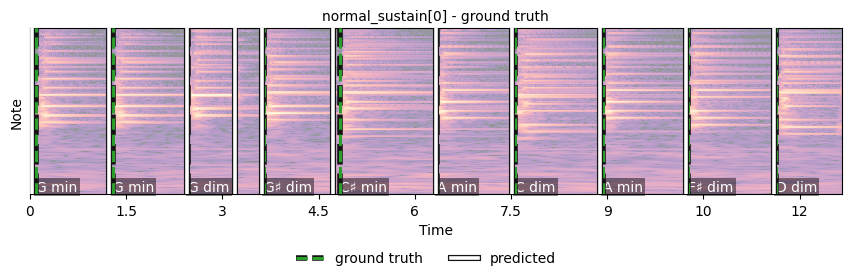

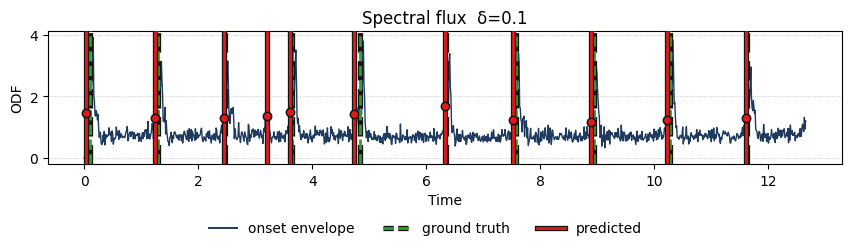

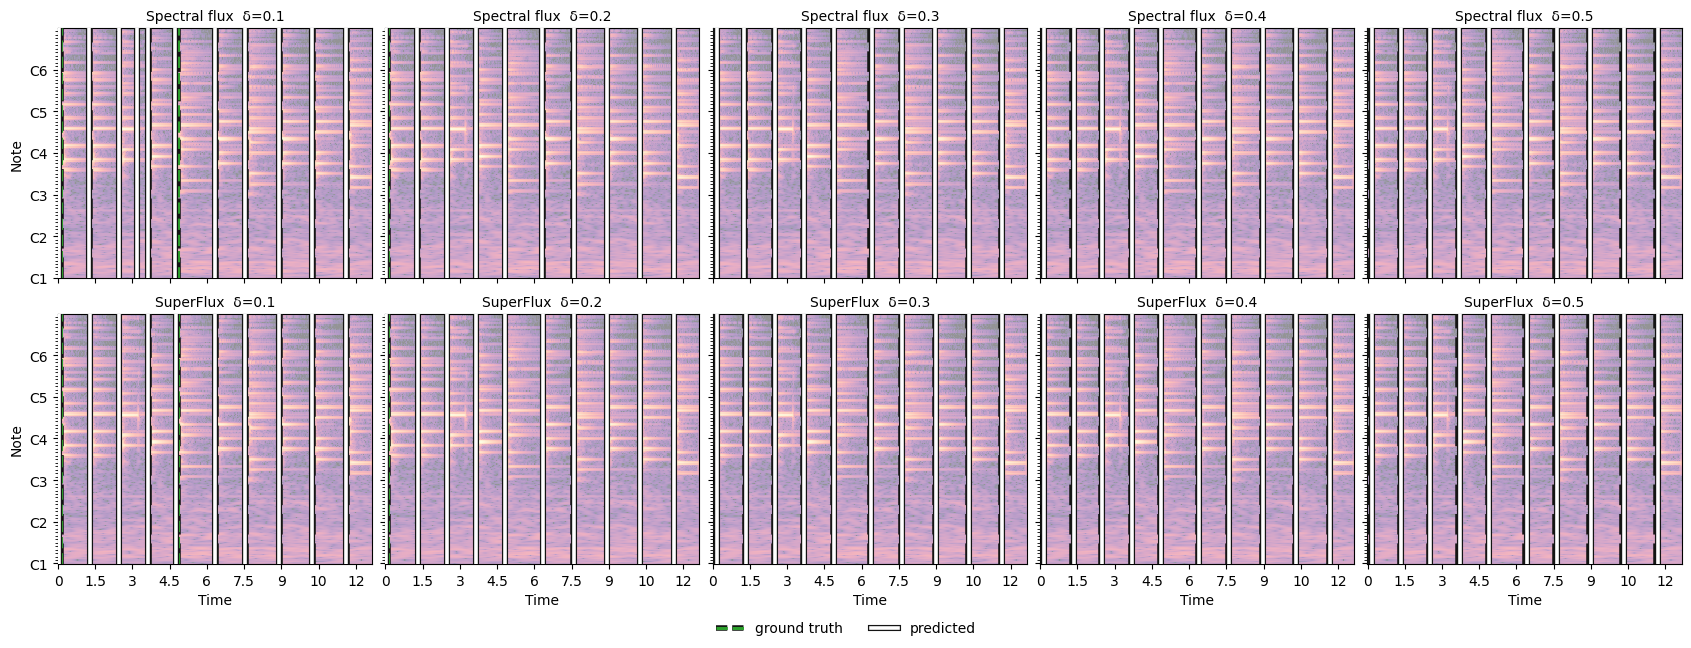

In [6]:
def detect_detail(sample_cqt: np.ndarray, odf: str, delta: float):
    envelope = librosa.onset.onset_strength(
        S=sample_cqt,
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        **ODF_KW[odf],
    )
    frames = librosa.onset.onset_detect(
        onset_envelope=envelope,
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        delta=delta,
        **PEAK_PICK,
    )
    times = librosa.frames_to_time(
        frames, sr=AUDIO_SAMPLE_RATE, hop_length=CQT_HOP_LENGTH
    ).astype(float)
    return envelope, frames.astype(int), times


def overlay_cqt(ax, sample_cqt, true_annotations, detected_times, title, chords=False):
    image = librosa.display.specshow(
        sample_cqt,
        x_axis="time",
        y_axis="cqt_note",
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        fmin=CQT_FMIN,
        bins_per_octave=CQT_BINS_PER_OCTAVE,
        ax=ax,
        alpha=SPEC_ALPHA,
    )
    y0 = ax.get_ylim()[0]
    _q = {"major": "maj", "minor": "min", "diminished": "dim"}
    for ev in true_annotations:
        outlined_vline(ax, ev["start"], color=GT_COLOR, ls="--", lw=GT_LW, zorder=4)
        if chords:
            parts = str(ev["chord"]).split("_")
            label = (
                f"{parts[0].replace('#', '♯')} {_q.get(parts[1], parts[1])}"
                if len(parts) > 1 else ev["chord"]
            )
            ax.text(
                ev["start"], y0, label,
                va="bottom", ha="left", fontsize=10, color="white",
                bbox=dict(facecolor="black", alpha=0.45, edgecolor="none", pad=1.4),
            )
    for t in np.atleast_1d(detected_times):
        outlined_vline(ax, t, color=PRED_COLOR, ls="-", lw=PRED_LW, zorder=6)
    ax.set_title(title, fontsize=10)
    return image


VIZ_ODF = "spectral-flux"
VIZ_DELTA = 0.10
_QUAL = {"major": "maj", "minor": "min", "diminished": "dim"}
envelope, pred_frames, pred_times = detect_detail(cqt, VIZ_ODF, VIZ_DELTA)
matched = match_events(ref, pred_times, WINDOW_S) if ref.size and pred_times.size else []
pred_for_ref = np.full(len(ref), np.nan)
pred_idx_for_ref = np.full(len(ref), np.nan)
ref_idx_for_pred = np.full(len(pred_times), np.nan)
for i_ref, i_est in matched:
    pred_for_ref[int(i_ref)] = float(pred_times[int(i_est)])
    pred_idx_for_ref[int(i_ref)] = int(i_est)
    ref_idx_for_pred[int(i_est)] = int(i_ref)

ann_table = pd.DataFrame(
    [
        {
            "index": i,
            "onset": float(ev["start"]),
            "pred index": pred_idx_for_ref[i],
            "predicted": pred_for_ref[i],
            "error (ms)": (
                (pred_for_ref[i] - float(ev["start"])) * 1000.0
                if np.isfinite(pred_for_ref[i]) else np.nan
            ),
            "chord": (
                f"{str(ev['chord']).split('_')[0].replace('#', '♯')} "
                f"{_QUAL.get(str(ev['chord']).split('_')[1], str(ev['chord']).split('_')[1])}"
                if "_" in str(ev["chord"]) else ev["chord"]
            ),
            "duration": float(ev["end"]) - float(ev["start"]),
        }
        for i, ev in enumerate(anns)
    ]
)
ann_table["pred index"] = ann_table["pred index"].astype("Int64")
det_table = pd.DataFrame(
    {
        "index": np.arange(len(pred_times), dtype=int),
        "predicted": pred_times,
        "gt index": ref_idx_for_pred,
        "extra": np.isnan(ref_idx_for_pred),
    }
)
det_table["gt index"] = det_table["gt index"].astype("Int64")
display(Markdown(
    f"**{VIZ_DATASET}[{VIZ_INDEX}]** — {len(ann_table)} annotated intervals, "
    f"{ODF_LABEL[VIZ_ODF]} δ={VIZ_DELTA:.1f}: "
    f"{len(pred_times)} predicted, {len(matched)} matched (50 ms)"
))
display(ann_table.round(3))
display(Markdown(
    f"**Detected onsets** — {len(det_table)} peaks "
    f"({int(det_table['extra'].sum())} unmatched extra)"
))
display(det_table.round(3))

fig, ax = plt.subplots(figsize=(8.4, 2.7), layout="constrained")
overlay_cqt(ax, cqt, anns, pred_times, f"{VIZ_DATASET}[{VIZ_INDEX}] - ground truth", chords=True)
fig.legend(
    handles=[
        line_handle(GT_COLOR, "--", GT_LW, "ground truth"),
        line_handle(PRED_COLOR, "-", PRED_LW, "predicted"),
    ],
    loc="outside lower center",
    ncol=2,
    frameon=False,
)
plt.show()

env_t = librosa.times_like(envelope, sr=AUDIO_SAMPLE_RATE, hop_length=CQT_HOP_LENGTH)
fig, ax = plt.subplots(figsize=(8.4, 2.4), layout="constrained")
ax.plot(env_t, envelope, color=NAVY, lw=1.0, zorder=2)
for t in ref:
    outlined_vline(ax, t, color=GT_COLOR, ls="--", lw=2.0, zorder=3)
for t in pred_times:
    outlined_vline(ax, t, color="#e31a1c", ls="-", lw=2.0, zorder=4)
if pred_frames.size:
    ax.scatter(
        pred_times, envelope[pred_frames], s=36, facecolor="#e31a1c", zorder=5,
        edgecolors=OUTLINE, linewidths=1.1,
    )
ax.set_xlabel("Time")
ax.set_ylabel("ODF")
ax.set_title(f"{ODF_LABEL[VIZ_ODF]}  δ={VIZ_DELTA:.1f}")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
fig.legend(
    handles=[
        Line2D([0], [0], color=NAVY, lw=1.4, label="onset envelope"),
        line_handle(GT_COLOR, "--", 2.0, "ground truth"),
        line_handle("#e31a1c", "-", 2.0, "predicted"),
    ],
    loc="outside lower center",
    ncol=3,
    frameon=False,
)
plt.show()

fig, axes = plt.subplots(
    len(ODFS), len(DELTAS), figsize=(16.8, 6.4),
    layout="constrained", sharex=True, sharey=True,
)
for row, odf in enumerate(ODFS):
    for col, delta in enumerate(DELTAS):
        _, _, est = detect_detail(cqt, odf, delta)
        title = f"{ODF_LABEL[odf]}  δ={delta:.1f}"
        overlay_cqt(axes[row, col], cqt, anns, est, title)
        if row < len(ODFS) - 1:
            axes[row, col].set_xlabel("")
        if col > 0:
            axes[row, col].set_ylabel("")
fig.legend(
    handles=[
        line_handle(GT_COLOR, "--", GT_LW, "ground truth"),
        line_handle(PRED_COLOR, "-", PRED_LW, "predicted"),
    ],
    loc="outside lower center",
    ncol=2,
    frameon=False,
)
plt.show()


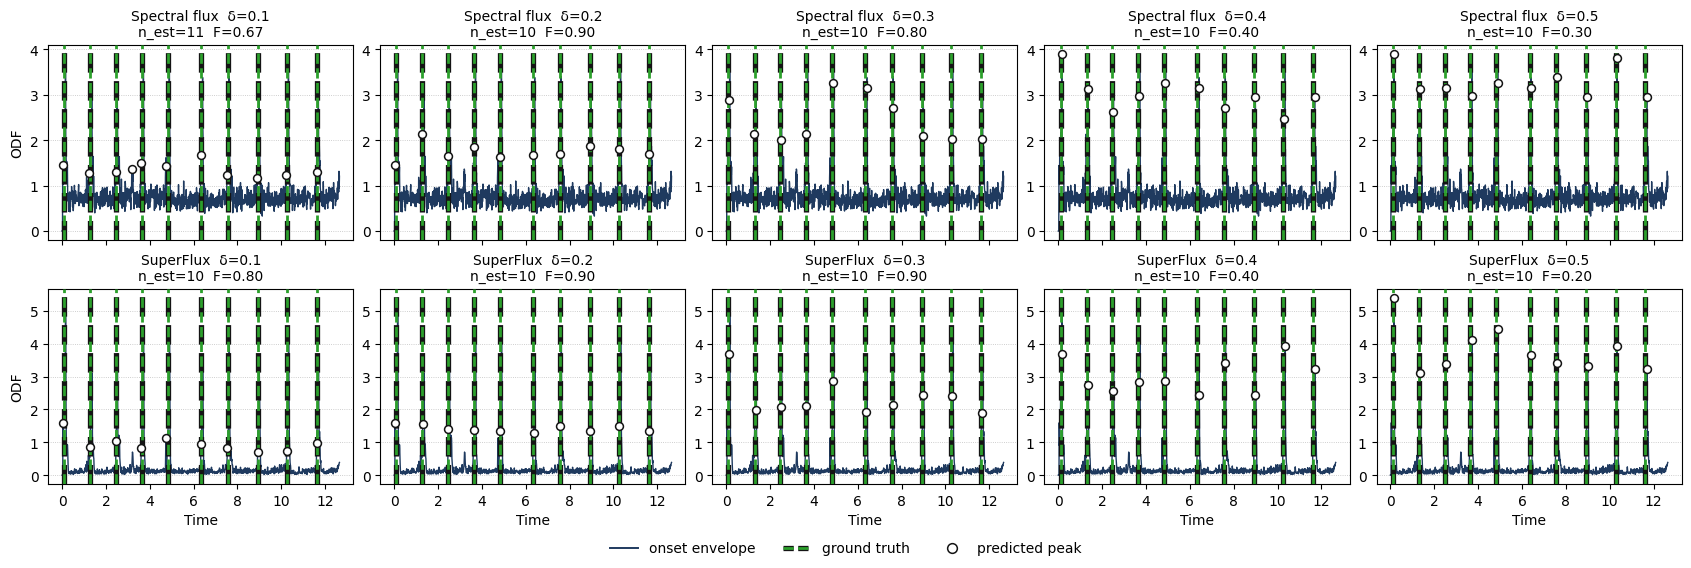

In [5]:
fig, axes = plt.subplots(
    len(ODFS), len(DELTAS), figsize=(16.8, 5.6),
    layout="constrained", sharex=True,
)
for row, odf in enumerate(ODFS):
    envelope, _, _ = detect_detail(cqt, odf, DELTAS[0])
    env_t = librosa.times_like(
        envelope, sr=AUDIO_SAMPLE_RATE, hop_length=CQT_HOP_LENGTH
    )
    for col, delta in enumerate(DELTAS):
        ax = axes[row, col]
        _, frames, est = detect_detail(cqt, odf, delta)
        metrics = sample_rows.loc[
            (sample_rows.odf == odf) & (sample_rows.delta == delta)
        ].iloc[0]
        ax.plot(env_t, envelope, color=NAVY, lw=1.0, zorder=2)
        for t in ref:
            outlined_vline(ax, t, color=GT_COLOR, ls="--", lw=2.0, zorder=3)
        if frames.size:
            ax.scatter(
                est, envelope[frames], s=32, facecolor=PRED_COLOR, zorder=5,
                edgecolors=OUTLINE, linewidths=1.1,
            )
        ax.set_title(
            f"{ODF_LABEL[odf]}  δ={delta:.1f}\n"
            f"n_est={int(metrics['n_est'])}  F={metrics['f-measure']:.2f}",
            fontsize=10,
        )
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
        if row == len(ODFS) - 1:
            ax.set_xlabel("Time")
        if col == 0:
            ax.set_ylabel("ODF")
fig.legend(
    handles=[
        Line2D([0], [0], color=NAVY, lw=1.4, label="onset envelope"),
        line_handle(GT_COLOR, "--", 2.0, "ground truth"),
        Line2D(
            [0], [0], color=PRED_COLOR, marker="o", ls="none",
            markersize=7, markeredgecolor=OUTLINE, markeredgewidth=1.1,
            label="predicted peak",
        ),
    ],
    loc="outside lower center",
    ncol=3,
    frameon=False,
)
plt.show()


### Vertical grid

Same sample and detectors as above, 5 δ rows × 2 ODF columns.

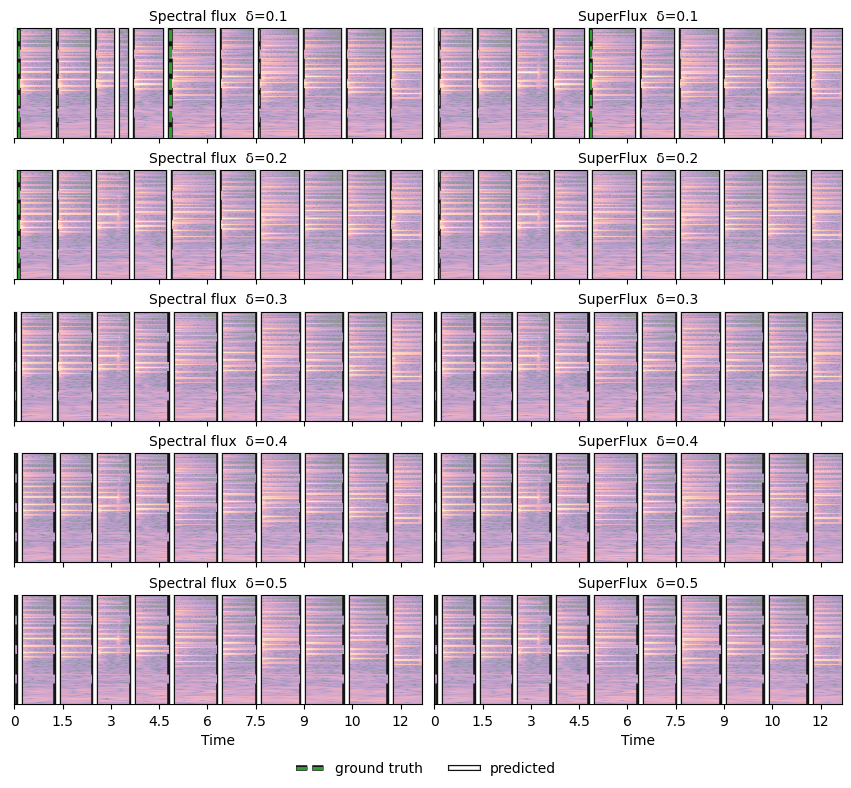

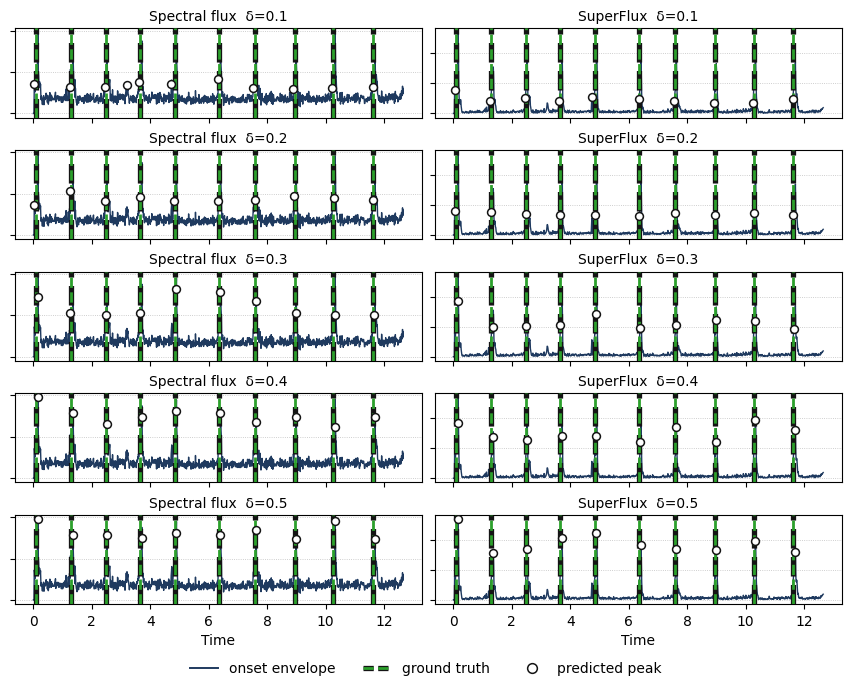

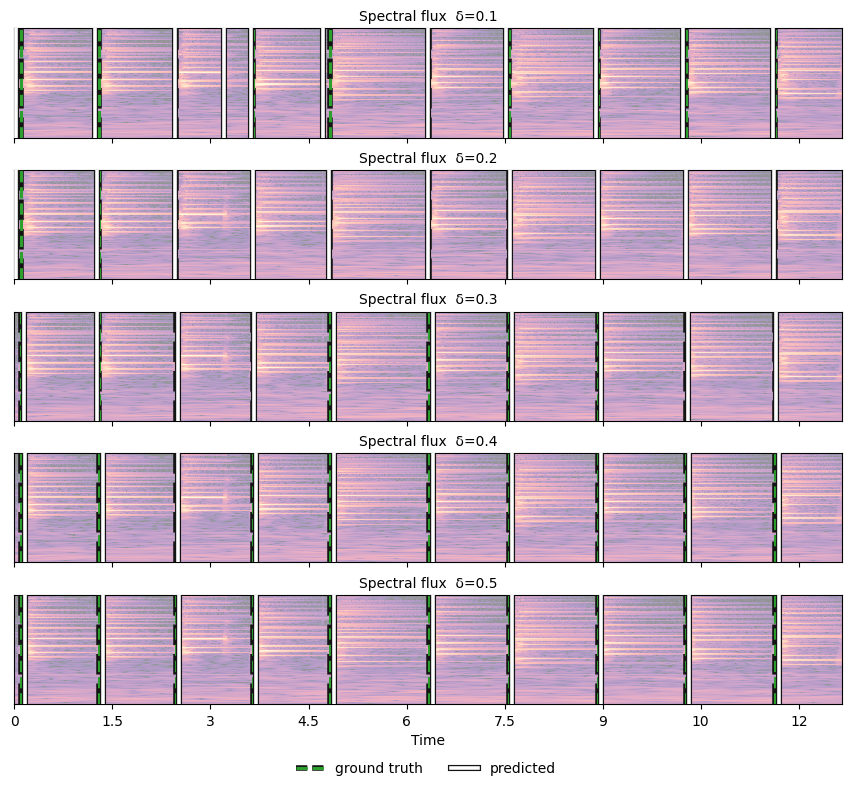

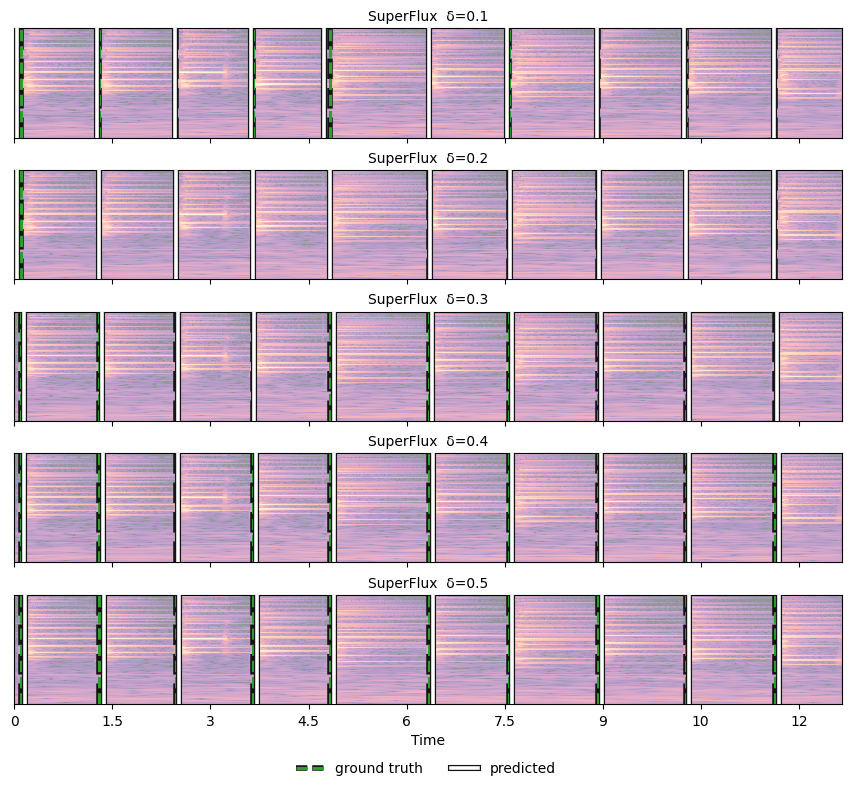

In [10]:
fig, axes = plt.subplots(
    len(DELTAS), len(ODFS), figsize=(8.4, 7.8),
    layout="constrained", sharex=True, sharey=True,
)
for col, odf in enumerate(ODFS):
    for row, delta in enumerate(DELTAS):
        ax = axes[row, col]
        _, _, est = detect_detail(cqt, odf, delta)
        overlay_cqt(ax, cqt, anns, est, f"{ODF_LABEL[odf]}  δ={delta:.1f}")
        if row < len(DELTAS) - 1:
            ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelleft=False)
fig.legend(
    handles=[
        line_handle(GT_COLOR, "--", GT_LW, "ground truth"),
        line_handle(PRED_COLOR, "-", PRED_LW, "predicted"),
    ],
    loc="outside lower center",
    ncol=2,
    frameon=False,
)
plt.show()

fig, axes = plt.subplots(
    len(DELTAS), len(ODFS), figsize=(8.4, 6.8),
    layout="constrained", sharex=True,
)
for col, odf in enumerate(ODFS):
    envelope, _, _ = detect_detail(cqt, odf, DELTAS[0])
    env_t = librosa.times_like(
        envelope, sr=AUDIO_SAMPLE_RATE, hop_length=CQT_HOP_LENGTH
    )
    for row, delta in enumerate(DELTAS):
        ax = axes[row, col]
        _, frames, est = detect_detail(cqt, odf, delta)
        metrics = sample_rows.loc[
            (sample_rows.odf == odf) & (sample_rows.delta == delta)
        ].iloc[0]
        ax.plot(env_t, envelope, color=NAVY, lw=1.0, zorder=2)
        for t in ref:
            outlined_vline(ax, t, color=GT_COLOR, ls="--", lw=2.0, zorder=3)
        if frames.size:
            ax.scatter(
                est, envelope[frames], s=32, facecolor=PRED_COLOR, zorder=5,
                edgecolors=OUTLINE, linewidths=1.1,
            )
        ax.set_title(
            f"{ODF_LABEL[odf]}  δ={delta:.1f}",
            fontsize=10,
        )
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
        if row == len(DELTAS) - 1:
            ax.set_xlabel("Time")
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelleft=False)
fig.legend(
    handles=[
        Line2D([0], [0], color=NAVY, lw=1.4, label="onset envelope"),
        line_handle(GT_COLOR, "--", 2.0, "ground truth"),
        Line2D(
            [0], [0], color=PRED_COLOR, marker="o", ls="none",
            markersize=7, markeredgecolor=OUTLINE, markeredgewidth=1.1,
            label="predicted peak",
        ),
    ],
    loc="outside lower center",
    ncol=3,
    frameon=False,
)
plt.show()

for odf in ODFS:
    fig, axes = plt.subplots(
        len(DELTAS), 1, figsize=(8.4, 7.8),
        layout="constrained", sharex=True, sharey=True,
    )
    for ax, delta in zip(axes, DELTAS):
        _, _, est = detect_detail(cqt, odf, delta)
        overlay_cqt(ax, cqt, anns, est, f"{ODF_LABEL[odf]}  δ={delta:.1f}")
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelleft=False)
    for ax in axes[:-1]:
        ax.set_xlabel("")
    fig.legend(
        handles=[
            line_handle(GT_COLOR, "--", GT_LW, "ground truth"),
            line_handle(PRED_COLOR, "-", PRED_LW, "predicted"),
        ],
        loc="outside lower center",
        ncol=2,
        frameon=False,
    )
    plt.show()
